## Key classification

Can we classify the key of a generation looking solely at its activations?

Smaller step: can we classify whether a piece is major or minor?

In [2]:
import numpy as np
from IPython.display import Audio
from scipy.io import wavfile
import os
from pathlib import Path
import librosa
import matplotlib.pyplot as plt

DATA_DIR = Path(os.path.abspath("./data"))

clip_id = "010"
audio_path = DATA_DIR / "audio" / f"{clip_id}.wav"

# Preview this audio
Audio(audio_path)

ModuleNotFoundError: No module named 'numpy'

In [30]:
# Krumhansl–Kessler profiles
kk_major = np.array([6.35, 2.23, 3.48, 2.33, 4.38, 4.09,
                     2.52, 5.19, 2.39, 3.66, 2.29, 2.88])
kk_minor = np.array([6.33, 2.68, 3.52, 5.38, 2.60, 3.53,
                     2.54, 4.75, 3.98, 2.69, 3.34, 3.17])

def best_match(chroma_vec, profile):
    # Produce major/minor profiles for each of the 12 notes
    scores = [np.corrcoef(chroma_vec, np.roll(profile, i))[0,1]
              for i in range(12)]
    return max(scores)

def get_chroma_cqt_keyscore(clip_id: str):
    """
    Use librosa.feature.chroma_cqt to get key of given wav file
    """
    wav_path = DATA_DIR / f"audio/{clip_id}.wav"
    y, sr = librosa.load(wav_path)

    # By default, bins are 512 samples wide 
    chroma = librosa.feature.chroma_cqt(y=y, sr=sr)

    chroma_mean = chroma.mean(axis=1)
    major_score = best_match(chroma_mean, kk_major)
    minor_score = best_match(chroma_mean, kk_minor)
    return major_score, minor_score

def get_midi_keyscore(clip_id: str):
    """
    Use pretty_midi to get key of given midi file
    """
    midi_path = DATA_DIR / f"midi/{clip_id}_basic_pitch.mid"
    midi = pretty_midi.PrettyMIDI(midi_path)
    
    # Empty pitch classes
    pc = np.zeros(12)

    for inst in midi.instruments:
        for note in inst.notes:
            duration = note.end - note.start
            pc[note.pitch % 12] += duration
    
    major_score = best_match(pc, kk_major)
    minor_score = best_match(pc, kk_minor)
    return major_score, minor_score

(0.5823065179921306, 0.9191716185317865)
(0.55349351706018, 0.8959176130785793)


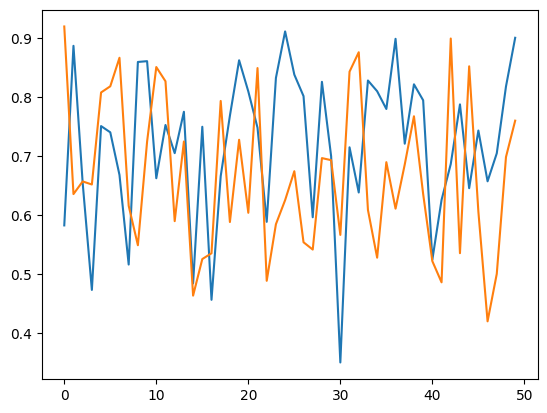

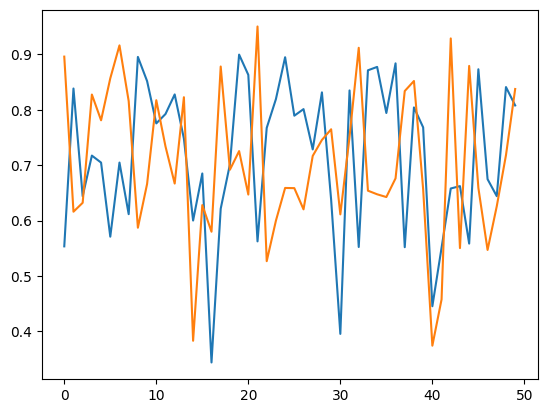

In [ ]:
print(get_chroma_cqt_keyscore("000"))
print(get_midi_keyscore("000"))

# Plot for several
maj_chroma = []
min_chroma = []

maj_midi = []
min_midi = []

for i in range(50):
    clip_id = f"{i:03d}"
    chroma = get_chroma_cqt_keyscore(clip_id)
    midi = get_midi_keyscore(clip_id)
    
    maj_chroma.append(chroma[0])
    min_chroma.append(chroma[1])
    
    maj_midi.append(midi[0])
    min_midi.append(midi[1])

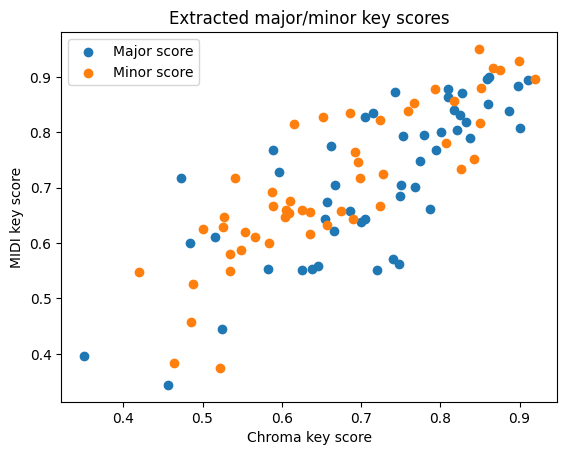

In [43]:
plt.scatter(maj_chroma, maj_midi, label="Major score")
plt.scatter(min_chroma, min_midi, label="Minor score")
plt.xlabel("Chroma key score")
plt.ylabel("MIDI key score")
plt.title("Extracted major/minor key scores")
plt.legend()
plt.show()

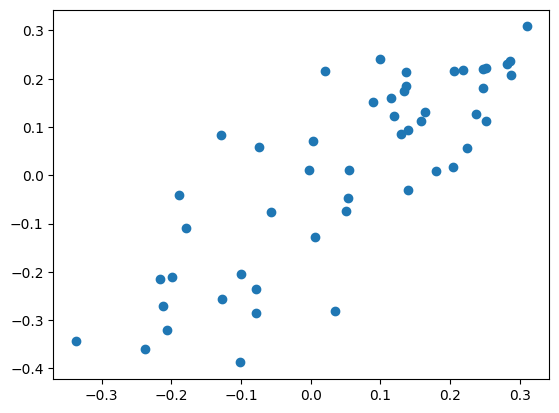

In [41]:
maj_chroma_np = np.array(maj_chroma)
min_chroma_np = np.array(min_chroma)
maj_midi_np = np.array(maj_midi)
min_midi_np = np.array(min_midi)

plt.scatter(maj_chroma_np - min_chroma_np, maj_midi_np - min_midi_np)